# 1D Warp Solution with a Gapped Surface Density
Notebook for solving and visualizing the linear 1D warp structure.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

plt.rcParams.update({"font.size": 16})

In [2]:
def solve_one_disk(r_min, r_max, alpha_func, epsilon_func, sigma_func, omega_func, H_func, use_epsilon=True):
    """Solve the steady 1D warp equations for a prescribed disk profile."""

    def rhs(r, y):
        W, G = y
        sigma = sigma_func(r)
        alpha = alpha_func(r)
        H = H_func(r)
        h = H / r
        omega = omega_func(r) if use_epsilon else r**(-1.5)
        epsilon = epsilon_func(r) if use_epsilon else 0.0

        dWdr_num = (-0.5j * epsilon + alpha) * G
        dWdr_den = 0.25 * sigma * H**2 * r**3 * omega**2
        dWdr = dWdr_num / dWdr_den

        # In this steady-state setup, G is taken to be constant.
        dGdr = 0.0 * W
        return [dWdr, dGdr]

    W_in, W_out = 0.0, 1.0
    y0 = [W_in, 1.0 + 0.0j]

    sol = solve_ivp(rhs, [r_min, r_max], y0, rtol=1e-12, dense_output=True)

    r = np.linspace(r_min, r_max, 2001)
    W = sol.sol(r)[0]
    G = sol.sol(r)[1]

    # Normalize so that W(r_max) = W_out.
    W *= W_out / W[-1]
    G *= W_out / W[-1]

    psi = r * np.gradient(W, r)
    return {"r": r, "Sigma": sigma_func(r), "W": W, "G": G, "psi": psi}


def make_disk_model(K, alpha0=0.0189, Sigma0=1.0, cs=0.02,
                    r_min=0.5, r_max=3.0, r_gap_in=1.0, r_gap_out=2.0,
                    d_edge_in=0.10, d_edge_out=0.20):
    """Build callable disk profiles for a gap depth parameter K."""

    def omega_K(r):
        return r**(-1.5)

    def H_disk(r):
        return cs / r**(-1.5)

    def h_disk(r):
        return cs / r**(-0.5)

    def gap_shape(r):
        return 1 + 0.5 * (K - 1) * (
            np.tanh((r - r_gap_in) / d_edge_in) - np.tanh((r - r_gap_out) / d_edge_out)
        )

    def alpha(r):
        return np.zeros_like(np.asarray(r), dtype=float) + alpha0

    def sigma(r):
        r = np.asarray(r)
        return Sigma0 * r**(-1.5) / gap_shape(r)

    r_temp = np.linspace(r_min * 0.5, r_max * 1.1, 1001)
    slope_gap = interp1d(
        r_temp,
        np.gradient(np.log(gap_shape(r_temp)), np.log(r_temp)),
        bounds_error=False,
        fill_value="extrapolate",
    )

    def omega(r):
        r = np.asarray(r)
        return omega_K(r) * np.sqrt(1 - h_disk(r) ** 2 * (3 + slope_gap(r)))

    kappa2 = interp1d(
        r_temp,
        np.gradient(omega(r_temp) ** 2 * r_temp**4, r_temp) / r_temp**3,
        bounds_error=False,
        fill_value="extrapolate",
    )

    def epsilon(r):
        r = np.asarray(r)
        return kappa2(r) / omega(r) ** 2 - 1

    return {
        "alpha": alpha,
        "sigma": sigma,
        "omega": omega,
        "epsilon": epsilon,
        "H": H_disk,
    }


def solve_models(K_list, **disk_kwargs):
    results = {}
    for K in K_list:
        model = make_disk_model(K, **disk_kwargs)
        results[K] = solve_one_disk(
            r_min=disk_kwargs.get("r_min", 0.5),
            r_max=disk_kwargs.get("r_max", 3.0),
            alpha_func=model["alpha"],
            epsilon_func=model["epsilon"],
            sigma_func=model["sigma"],
            omega_func=model["omega"],
            H_func=model["H"],
            use_epsilon=True,
        )
    return results

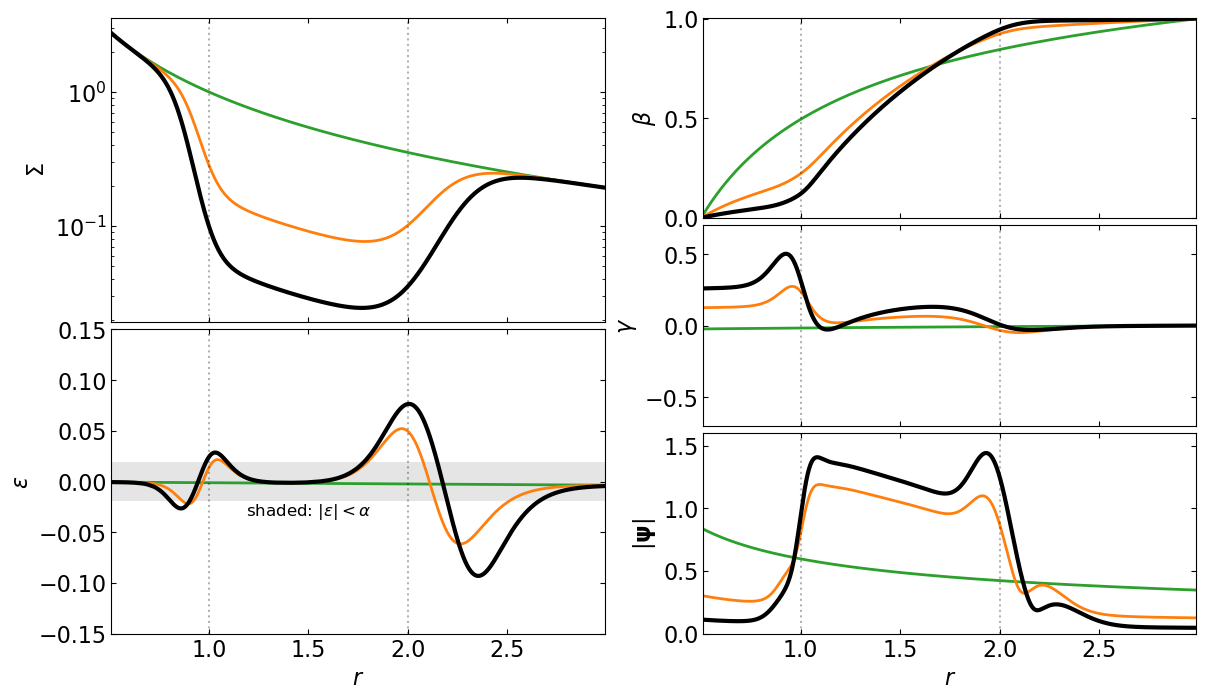

In [3]:
# Fiducial setup
r_min, r_max = 0.5, 3.0
R_gap_in, R_gap_out = 1.0, 2.0
K_list = [1, 6, 19]
colors = ["C2", "C1", "k"]

results = solve_models(
    K_list,
    alpha0=0.0189,
    Sigma0=1.0,
    cs=0.02,
    r_min=r_min,
    r_max=r_max,
    r_gap_in=R_gap_in,
    r_gap_out=R_gap_out,
    d_edge_in=0.10,
    d_edge_out=0.20,
)

fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(6, 2, hspace=0.08, wspace=0.20)

# Left column: 2 equal-height panels
ax00 = fig.add_subplot(gs[0:3, 0])              # Sigma
ax10 = fig.add_subplot(gs[3:6, 0], sharex=ax00) # epsilon

# Right column: 3 equal-height panels
ax01 = fig.add_subplot(gs[0:2, 1])              # beta
ax11 = fig.add_subplot(gs[2:4, 1], sharex=ax01) # gamma
ax21 = fig.add_subplot(gs[4:6, 1], sharex=ax01) # psi

for K, color in zip(K_list, colors):
    model = make_disk_model(
        K,
        alpha0=0.0189,
        Sigma0=1.0,
        cs=0.02,
        r_min=r_min,
        r_max=r_max,
        r_gap_in=R_gap_in,
        r_gap_out=R_gap_out,
        d_edge_in=0.10,
        d_edge_out=0.20,
    )
    res = results[K]
    lw = 3 if color == "k" else 2

    ax00.semilogy(res["r"], res["Sigma"], lw=lw, c=color, label=f"K={K}")
    ax10.plot(res["r"], model["epsilon"](res["r"]), lw=lw, c=color)
    ax01.plot(res["r"], np.abs(res["W"]), lw=lw, c=color)
    ax11.plot(res["r"], np.angle(res["W"]), lw=lw, c=color)
    ax21.plot(res["r"], np.abs(res["psi"]), lw=lw, c=color)

ax10.fill_between(
    [r_min, r_max],
    y1=-0.0189,
    y2=0.0189,
    color="k",
    alpha=0.1,
    ec=None,
)
ax10.text(
    1.5,
    -0.02,
    r"shaded: $|\epsilon| < \alpha$",
    ha="center",
    va="top",
    fontsize=12,
)

ax00.set_ylabel(r"$\Sigma$")
ax10.set_ylabel(r"$\epsilon$")
ax01.set_ylabel(r"$\beta$")
ax11.set_ylabel(r"$\gamma$")
ax21.set_ylabel(r"$|{\bf \psi}|$")

ax10.set_xlabel(r"$r$")
ax21.set_xlabel(r"$r$")

ax01.set_ylim([0.0, 1.005])
ax11.set_ylim([-0.7, 0.7])
ax21.set_ylim([0.0, 1.6])
ax10.set_ylim([-0.15, 0.15])

ax00.set_xlim([0.51, 2.99])
ax01.set_xlim([0.51, 2.99])

for ax in [ax00, ax10, ax01, ax11, ax21]:
    ax.tick_params(which="both", direction="in", right=True, top=True)
    ax.axvline(x=R_gap_in, c="k", ls=":", alpha=0.3)
    ax.axvline(x=R_gap_out, c="k", ls=":", alpha=0.3)

# Hide x tick labels except bottom row of each column
plt.setp(ax00.get_xticklabels(), visible=False)
plt.setp(ax01.get_xticklabels(), visible=False)
plt.setp(ax11.get_xticklabels(), visible=False)

# ax00.legend(frameon=False, loc="best")

plt.show()

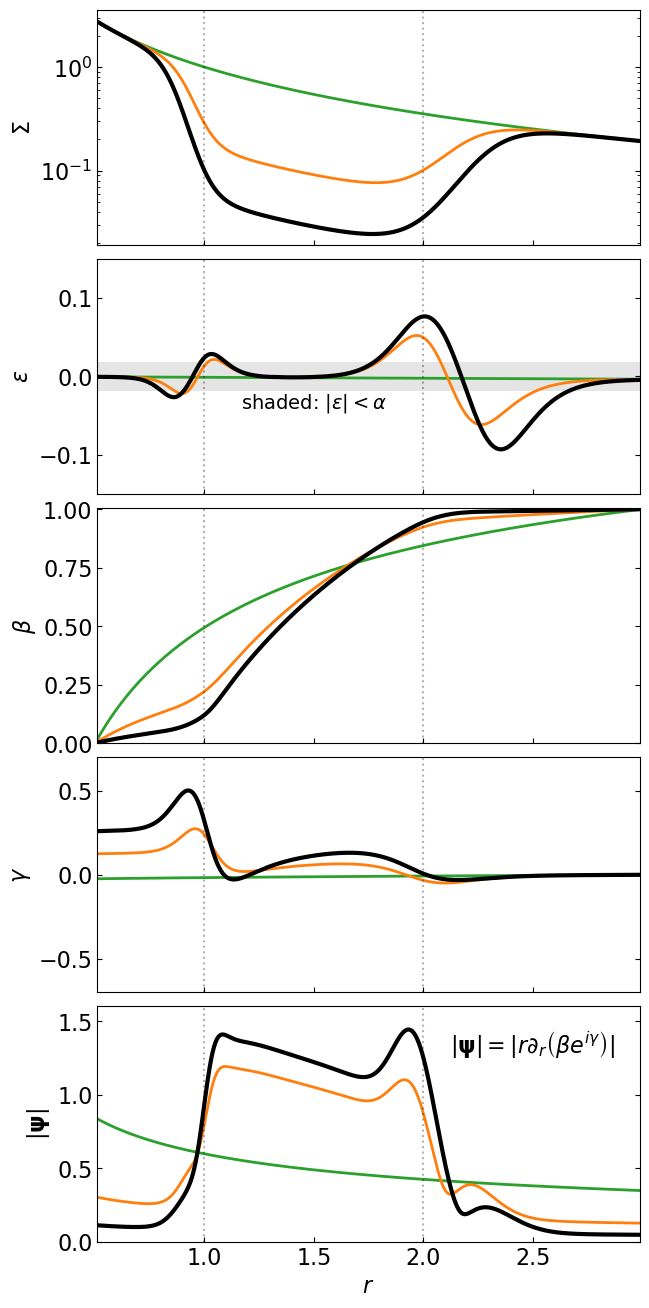

In [4]:
# Fiducial setup
r_min, r_max = 0.5, 3.0
R_gap_in, R_gap_out = 1.0, 2.0
K_list = [1, 6, 19]
colors = ["C2", "C1", "k"]

results = solve_models(
    K_list,
    alpha0=0.0189,
    Sigma0=1.0,
    cs=0.02,
    r_min=r_min,
    r_max=r_max,
    r_gap_in=R_gap_in,
    r_gap_out=R_gap_out,
    d_edge_in=0.10,
    d_edge_out=0.20,
)

fig, axes = plt.subplots(5, 1, figsize=(7, 16), sharex=True)
fig.subplots_adjust(hspace=0.06)

for K, color in zip(K_list, colors):
    model = make_disk_model(
        K,
        alpha0=0.0189,
        Sigma0=1.0,
        cs=0.02,
        r_min=r_min,
        r_max=r_max,
        r_gap_in=R_gap_in,
        r_gap_out=R_gap_out,
        d_edge_in=0.10,
        d_edge_out=0.20,
    )
    res = results[K]
    lw = 3 if color == "k" else 2

    axes[0].semilogy(res["r"], res["Sigma"], lw=lw, c=color, label=f"K={K}")
    axes[1].plot(res["r"], model["epsilon"](res["r"]), lw=lw, c=color)
    axes[2].plot(res["r"], np.abs(res["W"]), lw=lw, c=color)
    axes[3].plot(res["r"], np.angle(res["W"]), lw=lw, c=color)
    axes[4].plot(res["r"], np.abs(res["psi"]), lw=lw, c=color)

axes[1].fill_between([r_min, r_max], y1=-0.0189, y2=0.0189, color="k", alpha=0.1, ec=None)
axes[1].text(1.5, -0.02, r"shaded: $|\epsilon| < \alpha$", ha="center", va="top", fontsize=14)

axes[0].set_ylabel(r"$\Sigma$")
axes[1].set_ylabel(r"$\epsilon$")
axes[2].set_ylabel(r"$\beta$")
axes[3].set_ylabel(r"$\gamma$")
axes[4].set_ylabel(r"$|{\bf \psi}|$")
axes[4].set_xlabel(r"$r$")
axes[4].text(2.5,1.45,r'$|{\bf \psi}|=|r\partial_r \left(\beta e^{i\gamma}\right)|$',c='k',ha='center',va='top',fontsize=16)


axes[2].set_ylim([0.0, 1.005])
axes[3].set_ylim([-0.7, 0.7])
axes[4].set_ylim([0.0, 1.6])
axes[1].set_ylim([-0.15, 0.15])
axes[-1].set_xlim([0.51, 2.99])

for ax in axes:
    ax.tick_params(which="both", direction="in", right=True)
    ax.axvline(x=R_gap_in, c="k", ls=":", alpha=0.3)
    ax.axvline(x=R_gap_out, c="k", ls=":", alpha=0.3)

#axes[0].legend(frameon=False, loc="best")
plt.show()